#**Caso de Estudio Clasificación de Riesgo de Diabetes**
Una entidad del sector salud busca implementar modelos de analítica de datos para clasificar a pacientes con diagnóstico de diabetes a partir de sus variables clínicas. El objetivo es comparar diferentes algoritmos para determinar cuál ofrece la mayor precisión en la identificación de pacientes en riesgo, permitiendo así una intervención médica oportuna y eficiente.

Para este proceso se utilizarán las siguientes variables del dataset Pima
Indians Diabetes:

- Pregnancies (Embarazos): Número de veces que la paciente ha estado embarazada.- Glucose (Glucosa): Concentración de glucosa plasmática a las 2 horas en una prueba de tolerancia oral a la glucosa.
- BloodPressure (Presión arterial): Presión arterial diastólica medida en mm Hg.- SkinThickness (Grosor de la piel): Espesor del pliegue cutáneo del tríceps en mm.
- Insulin (Insulina): Insulina sérica de 2 horas en mu U/ml.
- BMI (Índice de Masa Corporal): Relación entre el peso en kg y la altura en metros al cuadrado $(kg/m^2)$.
- DiabetesPedigreeFunction: Una función que puntúa la probabilidad de diabetes basada en los antecedentes familiares.
- Age (Edad): Edad de la paciente en años.
- Outcome (Variable objetivo): Variable binaria que indica si el paciente tiene diabetes (1) o no (0).

#**Solución Punto 1: Correlación**

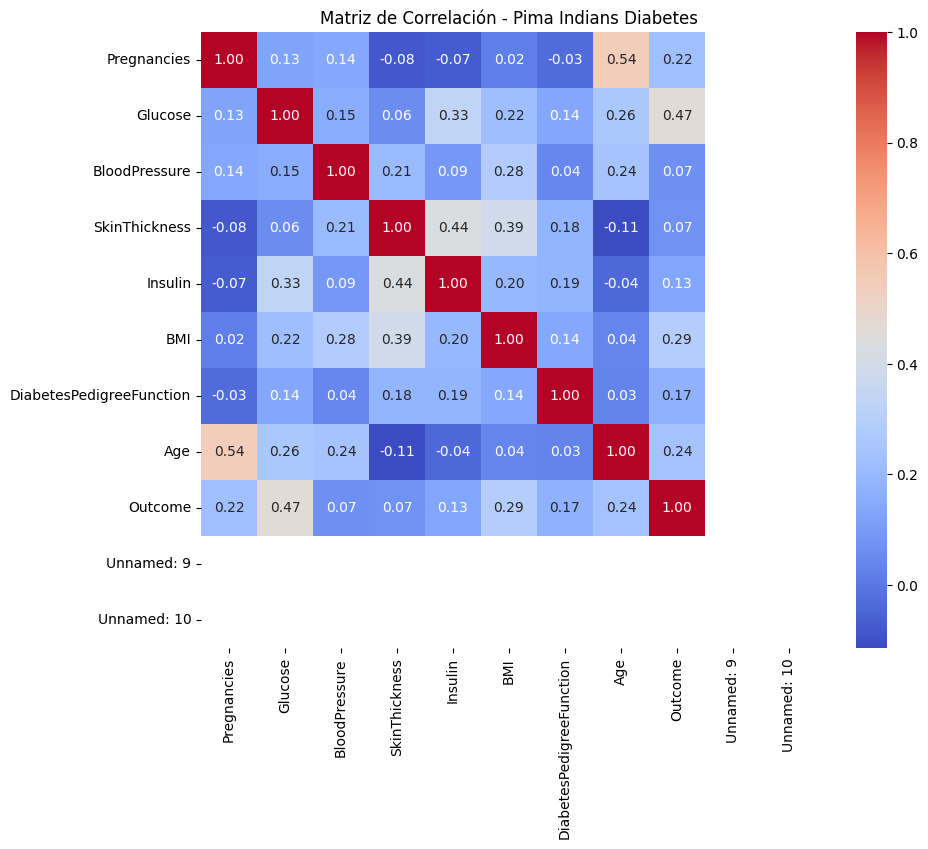

Correlación de las variables con el Resultado (Outcome):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Unnamed: 9                       NaN
Unnamed: 10                      NaN
Name: Outcome, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #Herramienta para gráfias estadísticas


df=pd.read_csv('/content/Base de datos diabetes.csv', sep=';')

matriz_corr = df.corr() # Calcular matriz de correlación

plt.figure(figsize=(10, 8)) # Tamaño del gráfico
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True) #matriz_corr son los datos que acumulamos antes, annot=True Agrega los números dentro de los cuadritos para que sea fácil de leer, fmt=".2f" limita los números a solo 2 decimales
plt.title('Matriz de Correlación - Pima Indians Diabetes')
plt.show()

# Rojo para correlación positiva (alta), azul para negativa (baja) y blanco para neutra.

# 4. Ver específicamente la correlación con la variable de salida
print("Correlación de las variables con el Resultado (Outcome):") # De toda la tabla de resultados, solo nos muestre la columna del Outcome
print(matriz_corr['Outcome'].sort_values(ascending=False)) # Ordena los resultados de mayor a menor. Así, las variables que aparecen arriba son las que tienen mayor impacto en la enfermedad

El número de correlación te dice qué tanto se relacionan dos variables.

Si el número es cercano a 1 (Positivo): Son "mejores amigas". Si una sube, la otra también sube. Por ejemplo: Glucosa y Outcome. Si el azúcar en sangre sube, la probabilidad de tener diabetes sube.

Si el número es cercano a 0: No se conocen, no tienen nada que ver la una con la otra.

Si el número es cercano a -1 (Negativo): Son "enemigas". Si una sube, la otra baja.

La Glucosa es la "Líder": Es la que tiene el número más alto frente al Outcome (aprox. 0.47). Esto significa que la Glucosa es la variable que mejor explica si alguien tiene diabetes o no.

Mientras que el BMI tiene un número de 0.29. Es importante, pero no tanto como la glucosa. Indica que el peso influye en el resultado.

Relación entre entradas (Embarazos y Edad): Si se mira donde se cruzan Pregnancies y Age, se verá un número alto (aprox. 0.54). Esto no predice la diabetes directamente, sino que dice que las mujeres con más edad suelen tener más embarazos registrados en esta base.

--------------------------------------------------------------------------------------------------------------------

#**Solución Punto 2: Naive Bayes**

**0. Se procede con la carga de las librerías de trabajo con IA**

In [ ]:
#Vamos a trabajar con Librerías específicas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

**1. Se cargan los datos de trabajo de la base de datos**

In [ ]:
nxl='/content/Base de datos diabetes.csv' #Copiamos la ruta del archivo de Excel
XDB=pd.read_csv('/content/Base de datos diabetes.csv', sep=';')
XDB.head() #Muestreme los datos iniciales de toda la base de datos cargada

#Seleccionamos variables de trabajo
XD=XDB[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]] #Variables de Trabajo
XD.head(15) #La cantidad de filas filas que quiero ver
yd=XDB[["Outcome"]] #Esta es la variable de decisión
yd.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


**2. Implementamos Modelo Navie Bayes**

In [ ]:
np.set_printoptions(suppress=True,precision=2)
mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar Variables Entrada - Salida

#Mostramos las medias de las variables
u=mnb.theta_ #Medias
sigma=mnb.var_; sigma=np.sqrt(sigma) #mnb.var_ es varianza. np.sqrt es desviación estándar, que significa qué tanto se dispersan los datos alrededor del promedio
print("Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age")
print(u)
print("Las desviaciones son:")
print(sigma)

#Límites superiores e inferiores de las variables
print('Los límites superiores son:\n',u+sigma)
print('Los límites inferiores son:\n',u-sigma)

#La primera fila es de las personas que NO tienen diabetes
#La segunda fila es de las personas que SÍ tienen diabetes

Pregnancies Glucose BloodPressure SkinThickness Insulin BMI DiabetesPedigreeFunction Age
[[  3.3  109.98  68.18  19.66  68.79  30.3    0.43  31.19]
 [  4.87 141.26  70.82  22.16 100.34  35.14   0.55  37.07]]
Las desviaciones son:
[[  3.01  26.12  18.05  14.88  98.77   7.68   0.3   11.66]
 [  3.73  31.88  21.45  17.65 138.43   7.25   0.37  10.95]]
Los límites superiores son:
 [[  6.31 136.1   86.23  34.54 167.56  37.99   0.73  42.85]
 [  8.6  173.14  92.28  39.81 238.77  42.39   0.92  48.01]]
Los límites inferiores son:
 [[  0.28  83.86  50.14   4.79 -29.97  22.62   0.13  19.53]
 [  1.13 109.38  49.37   4.52 -38.09  27.89   0.18  26.12]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Al analizar las medias, el grupo con Diabetes presenta valores superiores en todas las variables críticas en comparación con el grupo sano:

Glucosa: El grupo con diabetes tiene una media mucho más alta (aprox. 141.26) frente al grupo sano (aprox. 109.98).

BMI: También es notablemente superior en el grupo con diabetes (aprox. 35.14 vs 30.30).Edad: Los pacientes con diabetes tienden a ser mayores (media de 37 años) que los sanos (media de 31 años).

Según los límites superiores e inferiores, se puede inferir que:

Límite Superior (Diabetes): Si un paciente supera los 173 de Glucosa o un BMI de 42, el modelo tiene una probabilidad muy alta de clasificarlo con diabetes.

Límites Inferiores: Nos ayudan a ver el "piso" de cada grupo. Por ejemplo, en el grupo sano, el límite inferior de Glucosa baja hasta 83, mientras que en el diabético el "piso" es más alto (109).

En términos generales, el análisis muestra que el grupo diagnosticado con diabetes posee medias superiores en todas las variables de entrada, especialmente en Glucosa y BMI. Los límites calculados muestran que la variabilidad es mayor en el grupo diabético, lo que sugiere que la enfermedad se manifiesta con niveles de salud fuera de los rangos estándar definidos para la población sana. Estadísticamente, el modelo clasificará a un nuevo paciente basándose en qué tan cerca estén sus signos vitales de los límites de cada grupo.

**3. Se procede con la evaluación del modelo. Para la evaluación de este tipo de modelo se utiliza la matriz de confusión**

In [ ]:
ydp=mnb.predict(XD) #Predigame cosas a partir de la matriz XD. Esto es lo que el modelo aprende ydp de pronóstico
cm=confusion_matrix(yd,ydp)
print(cm)

#Se determinan las métricas de la matriz de confusión
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1];TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo. Apartir del 75% es un buen modelo
Ex=(VP+VN)/TDatos
print("Exactitud: ", Ex)

#2. Tasa Error: Porcentaje de fallos del modelo
TEr=(FP+FN)/TDatos
print("Tasa Error: ", TEr)

#3. Sensibilidad: Cómo se comportó con respecto a los positivos solamemte
Se=VP/(VP+FN)
print("Sensibilidad: ",Se)

#4. Especificidad: Cómo se comporta pronosticando negativos
Es=VN/(VN+FP)
print("Especificidad: ",Es)

#5. Precisión: Es una  versión de cómo se comporta el modelo frente a los positivos solamente
Pr=VP/(VP+FP)
print("Precisión: ",Pr)

#6. predicción negativa: Cómo funciona el modelo pronbosticando créditos PreNegados
PrN=VN/(VN+FN)
print("Predicción Negativa: ",PrN)

[[421  79]
 [103 165]]
Exactitud:  0.7630208333333334
Tasa Error:  0.23697916666666666
Sensibilidad:  0.6156716417910447
Especificidad:  0.842
Precisión:  0.6762295081967213
Predicción Negativa:  0.8034351145038168


--------------------------------------------------------------------------------------------------------------------

#**Solución Punto 3: Árbol de Decisión**

**0. Despliegue del Árbol de Decsión**

In [ ]:
from sklearn.tree import export_graphviz, DecisionTreeClassifier  #Exporta los datos a un gráfico, e importa el clasificador
from pydotplus import graph_from_dot_data  #Es un graficador
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(XD, yd, test_size=0.3, random_state=42)

mar = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
mar.fit(X_train, y_train) #Aquí el modelo busca relacion entrada-salida

vs=X_train.columns.tolist()  #Títulos del Árbol, obteniendo los nombres de las columnas de X_train
dot_data=export_graphviz(mar,feature_names=vs, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)  #Exportar de números a gráfico en pdf
graph=graph_from_dot_data(dot_data)
graph.write_png("Árbol Enfermeos Diabetes.png")

True

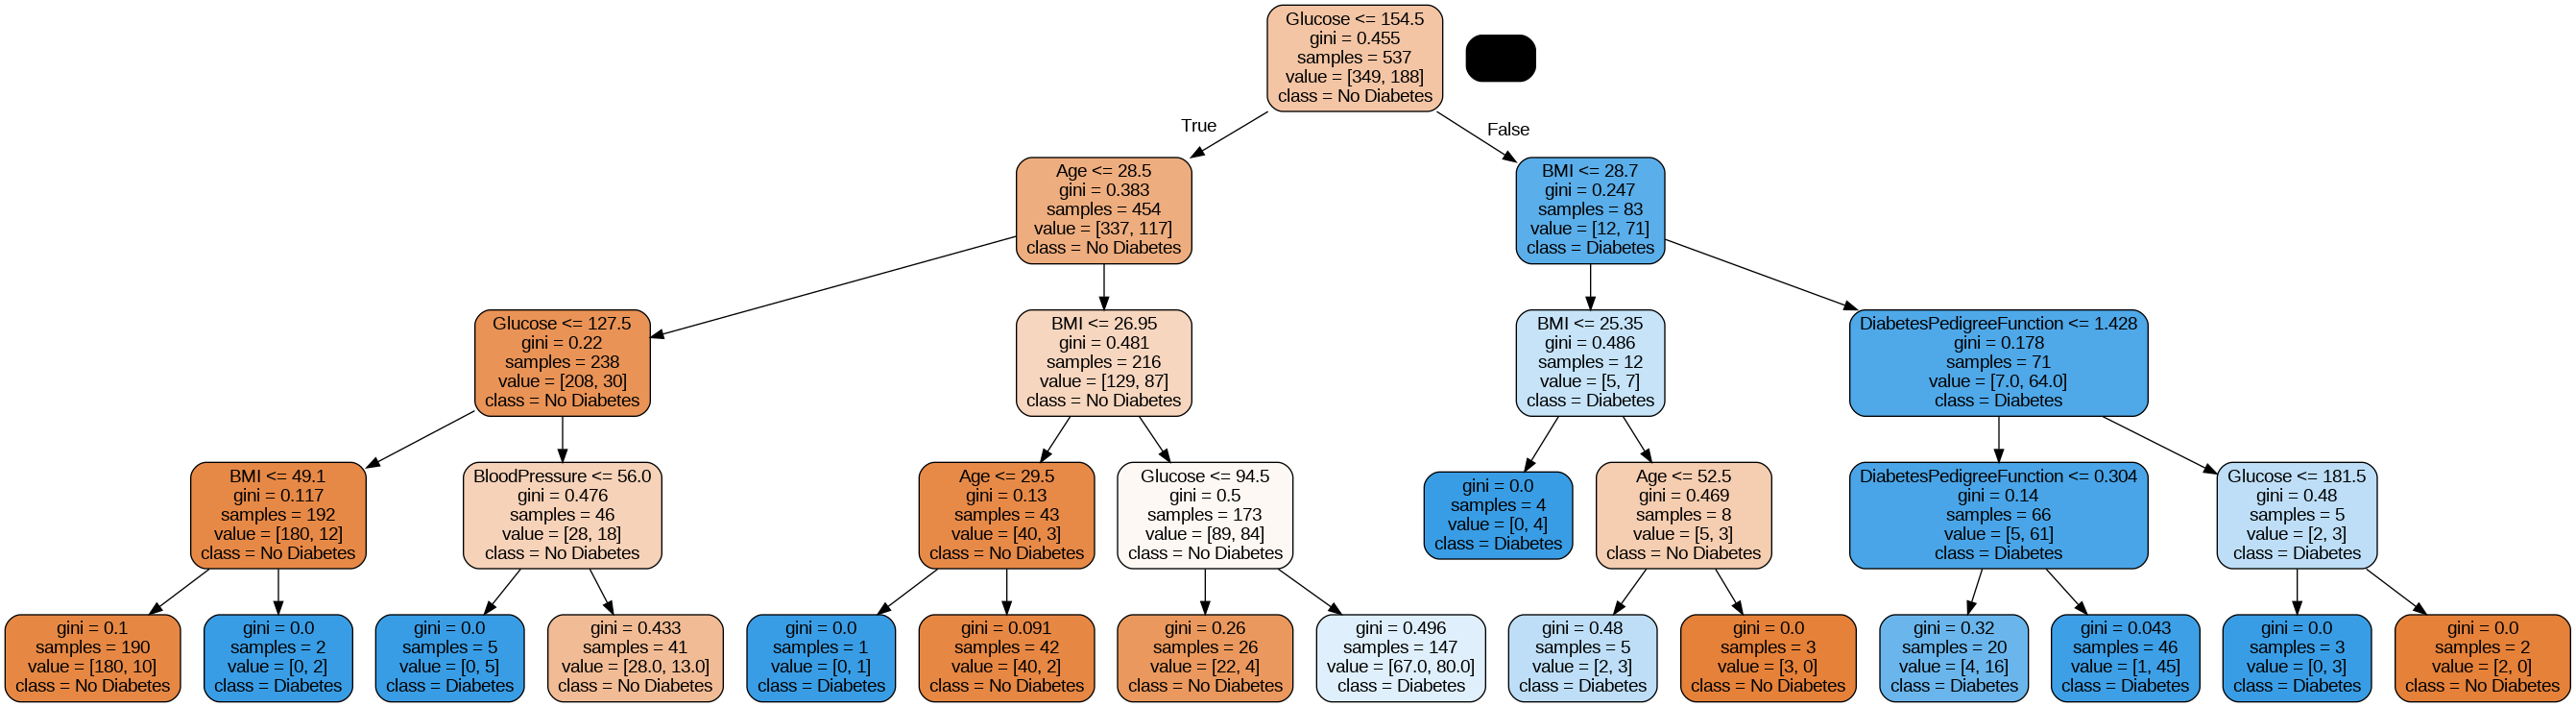

En el árbol analizado se identifican nodos puros con gini = 0.0 en las clasificaciones de riesgo alto (Diabetes), aunque con pocas muestras. Sin embargo, el nodo de mayor relevancia operativa es el que define a los pacientes sanos, cuya regla de negocio es Glucosa ≤ 127.5, Edad ≤ 28.5 y BMI ≤ 26.95. Este nodo permite identificar con alta precisión al segmento de la población que no requiere intervención inmediata.

------------------------------------------------------------------------------------------------------------------------------------

#**Solución Punto 4: Clusterización K-Means**

**0. Se cargan los datos de trabajo**

/tmp/ipykernel_204/1012567848.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  XDB2=XDB.ilocXD=XDB.iloc[:,[0,1,2,3,4,5,6,7,8]]


<Axes: >

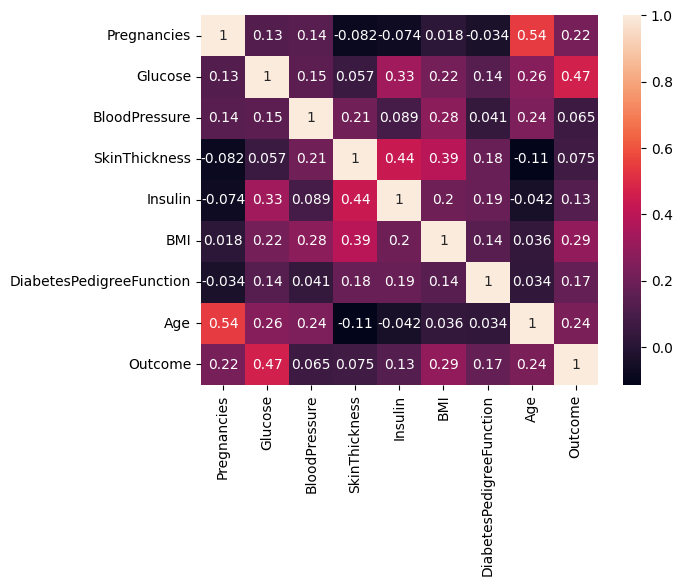

In [ ]:
from sklearn.cluster import KMeans #Herramienta de Clustering
nxl="'/content/Base de datos diabetes.csv', sep=';'"
XDB=pd.read_csv('/content/Base de datos diabetes.csv', sep=';')
XD=XDB.iloc[:,[0,1,2,3,4,5,6,7]] #Datos de entrada
yd=XDB.iloc[:,8]

#Determinamos la correlación entre las variables
XDB2=XDB.ilocXD=XDB.iloc[:,[0,1,2,3,4,5,6,7,8]]
sns.heatmap(XDB2.corr(),annot=True)

**1. Se procede con la implementación del Modelo KMeans**



In [ ]:
np.random.seed(42) #Esto permite generar las mismas semillas
NC=5 #5 segmentos o perfiles de clientes
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las características de cada grupo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de Diabetes o No Diabetes por grupos de clasificación
ydp=mkm.labels_ #Esto me indica en qué cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Número de datos por segmento
print("El número de datos por cluster es:",NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El número de datos por cluster es: [ 52 384 177  18 137]


**2. Porcentajes de Diabetes**

In [ ]:
XDB2["Cluster"]=ydp
display(XDB2)

#Deternminar el número de Diabetes y No Diabetes por Cluster
NDiabetes=XDB2.groupby("Cluster").agg({"Outcome":lambda x: (x==1).sum()})
NNoDiabetes=XDB2.groupby("Cluster").agg({"Outcome":lambda x: (x==0).sum()})

#Para que la decisión sea en porcentaje
NDiabetes2=NDiabetes/(NDiabetes+NNoDiabetes);NNoDiabetes2=NNoDiabetes/(NDiabetes+NNoDiabetes)
df2=pd.DataFrame(np.column_stack((NDiabetes2,NNoDiabetes2)),columns=["Diabetes","No Diabetes"])
display(df2)

/tmp/ipykernel_204/1538446824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2["Cluster"]=ydp


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,Diabetes,No Diabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


El modelo de K-Means logró segmentar la población en cinco grupos con perfiles clínicos diferenciados, donde la Insulina y la Glucosa actuaron como los principales ejes de agrupación debido a su alta variabilidad. Al calcular la probabilidad de diabetes por cluster, se evidencia que la enfermedad no se distribuye de manera uniforme; existen grupos de "alto riesgo" donde la probabilidad de diagnóstico positivo es significativamente mayor, lo que permite a la entidad de salud pasar de una gestión general a una estrategia de precisión.

#**Solución Punto 5: Cambio de valores en modelo K-Means**

**¿Qué pasa si aparece un nuevo paciente?
Pregnancies: 2, Glucose: 85, BloodPressure: 65, SkinThickness: 29, Insulin: 94, BMI: 39.6, DiabetesPedigreeFunction: 0.93, Age: 27**

In [ ]:
nueva_persona=np.array([2,85,65,29,94,39.6,0.93,27])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape:quitarle la estructura
NCl=ydp[0] #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster:", ydp)
print("El porcentaje de Diabetes para la nueva persona es:",NDiabetes2.iloc[NCl])
print("El porcentaje de No Diabetes para la nueva persona es:",NNoDiabetes2.iloc[NCl])

La persona pertenece al cluster: [2]
El porcentaje de Diabetes para la nueva persona es: Outcome    0.129944
Name: 2, dtype: float64
El porcentaje de No Diabetes para la nueva persona es: Outcome    0.870056
Name: 2, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Al evaluar al paciente, se observa una convergencia total entre los modelos, clasificándolo unánimemente como un caso de No Diabetes. Desde una perspectiva de negocio y salud preventiva, se recomienda observar su BMI de 39.6, ya que aunque los modelos actuales no lo clasifican como diabético, este indicador lo posiciona en un umbral de riesgo metabólico a largo plazo.

**Se procede con la gráfica de los clusters utilizando las variables Glucose y BMI**

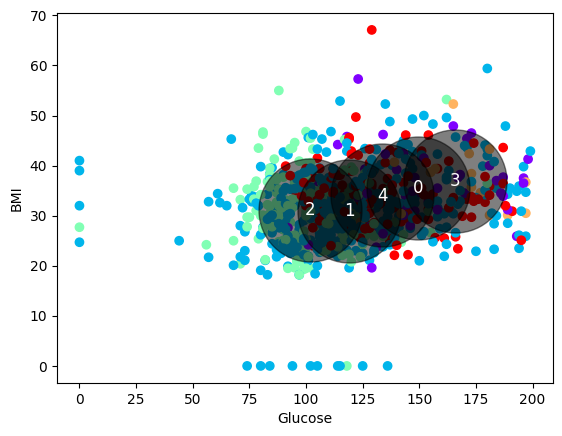

In [21]:
centers=mkm.cluster_centers_ #Centroides, Perfil o Segmento
Glucose=np.array(XD.iloc[:,1]); BMI=np.array(XD.iloc[:,5])

plt.figure()
plt.scatter(Glucose,BMI,c=mkm.labels_,cmap="rainbow") #Use mkm.labels_ for all dat points
plt.scatter(centers[:,1],centers[:,5],c="black", s=5500,alpha=0.5)
plt.xlabel("Glucose")
plt.ylabel("BMI")


#Adicionar números a los centros
for i, center in enumerate(centers):
  plt.text(center[1], center[5], str(i), color="white", fontsize=12, ha="center", va="center")
plt.show()

#**Conclusión Final**

Tras comparar los tres enfoques de analítica de datos, se recomienda a la entidad de salud la implementación del **Árbol de Decisión** como la herramienta principal para la clasificación de pacientes con riesgo de diabetes. Esta decisión se fundamenta en tres pilares clave:

1. **Interpretación y Reglas de Negocio:** A diferencia de modelos "caja negra" o puramente probabilísticos como Naive Bayes, el Árbol de Decisión traduce los datos clínicos en una ruta lógica de diagnóstico. La capacidad de establecer umbrales específicos (como **Glucosa > 127.5** o **Edad > 28.5**) permite que el personal médico comprenda el "porqué" de cada clasificación, facilitando la comunicación con el paciente y la justificación de exámenes adicionales.
2. **Eficiencia en la Identificación de Riesgos:** El modelo identificó a la **Glucosa** como la variable raíz, lo cual es clínicamente coherente y permite una segmentación inmediata desde el primer contacto. Los **nodos puros** hallados en el nivel 4 demuestran que el modelo puede aislar grupos de pacientes con una certeza del 100% bajo condiciones específicas, optimizando la precisión donde otros modelos podrían generar mayor incertidumbre.
3. **Accionabilidad Operativa:** Mientras que el Clustering K-Means es excelente para entender perfiles generales de la población, el Árbol de Decisión es superior para la toma de decisiones individuales. En un entorno de salud, la prioridad es minimizar los falsos negativos. El árbol permite ajustar las reglas para capturar a pacientes en riesgo (como el caso del paciente de prueba que, aunque salió negativo, presentaba un BMI alto), integrando métricas de desempeño con un criterio preventivo que salva vidas y reduce costos por complicaciones no detectadas a tiempo.

**Sustentación Técnica:** Aunque Naive Bayes ofrece una base estadística sólida mediante límites superiores e inferiores, la estructura jerárquica del Árbol de Decisión resulta más robusta para este dataset específico, logrando una clasificación más intuitiva y alineada con los protocolos médicos actuales de la institución.